A notebook to compare MPAS simulations with a w=0 initial condition
and a nonzero initial vertical velocity.
This notebook makes figures for the paper.

In [61]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import cmaps

In [62]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

def cubic_z_interp(h, field_vals_all, lon, lat, z_val):
    # Now make cubic interpolation coefficients for each grid staggering

    # Use the bottom four levels (in Python notation!)
    levels = [-1, -2, -3, -4]
    
    coeffs = np.zeros((4, len(lat), len(lon)))

    # Compute weights using interpolating polynomials
    coeffs[0] = (
        (z_val - h[levels[1]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[0]] - h[levels[1]]) * (h[levels[0]] - h[levels[2]])
        * (h[levels[0]] - h[levels[3]])
    )
    coeffs[1] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[1]] - h[levels[0]]) * (h[levels[1]] - h[levels[2]])
        * (h[levels[1]] - h[levels[3]])
    )
    coeffs[2] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[2]] - h[levels[0]]) * (h[levels[2]] - h[levels[1]])
        * (h[levels[2]] - h[levels[3]])
    )
    coeffs[3] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[2]])
    ) / (
        (h[levels[3]] - h[levels[0]]) * (h[levels[3]] - h[levels[1]])
        * (h[levels[3]] - h[levels[2]])
    )

    field_vals = np.zeros((len(lat), len(lon)))
    
    for i in np.arange(4):
        field_vals += coeffs[i]*field_vals_all[levels[i]]

    # Set values below surface to NaN
    field_vals = np.where(
        h[levels[0]] > z_val, np.nan, field_vals
    )
    
    return field_vals

In [63]:
rot = True
u0 = 10
X = 20

dycore = 'CAM-MPAS'
res = 'mpasa60'
test_name_start = 'cam_6_4_080'

#lev_no_zero = 'L20km_L57'
#extra_name_zero = '_tau_1_10'

lev_no_zero = 'L20km_L57_new_RF_w0'
extra_name_zero = '_tau100s'


#lev_no_nonzero = 'L20km_L57_nonzero_w2'
#extra_name_nonzero = '_nonzero_w0_sign_flipped'
#if rot:
#    extra_name_nonzero = '_nonzero_w0'
#else:
#    extra_name_nonzero = '_nonzero_w'

lev_no_nonzero = 'L20km_L57_new_RF'
extra_name_nonzero = '_tau100s'

case_zero = f'{test_name_start}_paper_six_{res}_{lev_no_zero}'
case_nonzero = f'{test_name_start}_paper_six_{res}_{lev_no_nonzero}'

if rot:
    nc_file_zero = f'{case_zero}.cam.h0i.0001-01-01-00000_gap_with_rot{extra_name_zero}.regrid.0.5x0.5.nc'
    nc_file_nonzero = f'{case_nonzero}.cam.h0i.0001-01-01-00000_gap_with_rot{extra_name_nonzero}.regrid.0.5x0.5.nc'
else:
    nc_file_zero = f'{case_zero}.cam.h0i.0001-01-01-00000_gap_omega0{extra_name_zero}.regrid.0.5x0.5.nc'
    nc_file_nonzero = f'{case_nonzero}.cam.h0i.0001-01-01-00000_gap_omega0{extra_name_nonzero}.regrid.0.5x0.5.nc'

In [64]:
run_base = "/glade/derecho/scratch/timand/"

run_path_zero = run_base + case_zero + '/run/' + nc_file_zero
run_path_nonzero = run_base + case_nonzero + '/run/' + nc_file_nonzero

nc_zero = Dataset(run_path_zero)
nc_nonzero = Dataset(run_path_nonzero)

time = nc_zero['time'][:]
lev = nc_zero['lev'][:]
lat = nc_zero['lat'][:] 
lon = nc_zero['lon'][:] 
print(lev[-1])

LON, LAT = np.meshgrid(lon,lat)

50.00000111758712


In [65]:
# Initial omega

lev_index = -1

omega_zero = nc_zero['OMEGA'][0, lev_index, :, :]
omega_nonzero = nc_nonzero['OMEGA'][0, lev_index, : ,:]
#print(np.shape(omega))
#omega_field = omega[0, lev_index,:,:]
#T_field = nc['T'][0, lev_index, :,:]
#P = lev[lev_index]
#P_Pa = P*100

# Convert OMEGA to w:
Rd = 287.04
g = 9.80616
T0 = 288
#P_Pa = lev[lev_index]*100
P_Pa = nc_zero['PS'][0, :,:]

print(np.min(P_Pa), np.max(P_Pa))

print(Rd*T0/g/P_Pa)

w_zero = -(Rd/g)*omega_zero*T0/P_Pa
w_nonzero = -(Rd/g)*omega_nonzero*T0/P_Pa

# Normalised fields:
deg2rad = np.pi/180
T0 = 288
u0 = 10

U_field_vals1 = (nc_zero['OMEGA'][0, lev_index, :, :] - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2 = (nc_nonzero['OMEGA'][0, lev_index, :, :] - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

88349.62 105844.91
[[0.08430154621601105 0.08430154621601105 0.08430154621601105 ...
  0.08430154621601105 0.08430154621601105 0.08430154621601105]
 [0.08430112153291702 0.08430111408233643 0.08430111408233643 ...
  0.08430112153291702 0.08430112153291702 0.08430112153291702]
 [0.08430000394582748 0.08430000394582748 0.08430000394582748 ...
  0.08430001139640808 0.08430001139640808 0.08430000394582748]
 ...
 [0.08430012315511703 0.08430012315511703 0.08430013805627823 ...
  0.08430008590221405 0.08430010080337524 0.08430011570453644]
 [0.08430102467536926 0.08430101722478867 0.08430101722478867 ...
  0.08430102467536926 0.08430102467536926 0.08430102467536926]
 [0.08430161327123642 0.08430161327123642 0.08430162072181702 ...
  0.08430160582065582 0.08430160582065582 0.08430161327123642]]


Maximum omega is 0.0 Pa/s
Minimum omega is 0.0 Pa/s
Maximum omega is 27.34322738647461 Pa/s
Minimum omega is -27.018983840942383 Pa/s


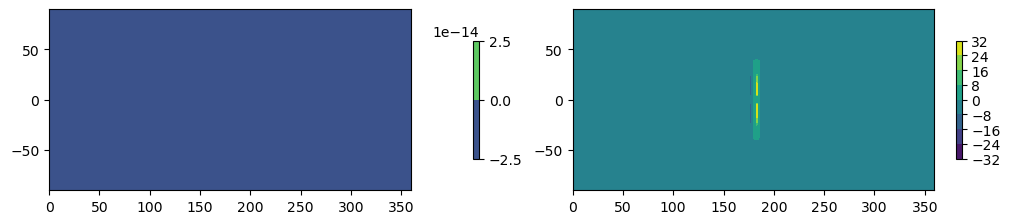

In [66]:
# Plot! OMEGA first
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,6), constrained_layout=True)
plot1 = ax1.contourf(LON, LAT, omega_zero)
plot2 = ax2.contourf(LON, LAT, omega_nonzero)

ax1.set_aspect('equal')
ax2.set_aspect('equal')

plt.colorbar(plot1,shrink=0.2)
plt.colorbar(plot2,shrink=0.2)

print(f'Maximum omega is {np.max(omega_zero)} Pa/s')
print(f'Minimum omega is {np.min(omega_zero)} Pa/s')

print(f'Maximum omega is {np.max(omega_nonzero)} Pa/s')
print(f'Minimum omega is {np.min(omega_nonzero)} Pa/s')

Maximum vertical velocity is -0.0 m/s
Minimum vertical velocity is -0.0 m/s
Maximum vertical velocity is 2.3715734481811523 m/s
Minimum vertical velocity is -2.3732025623321533 m/s


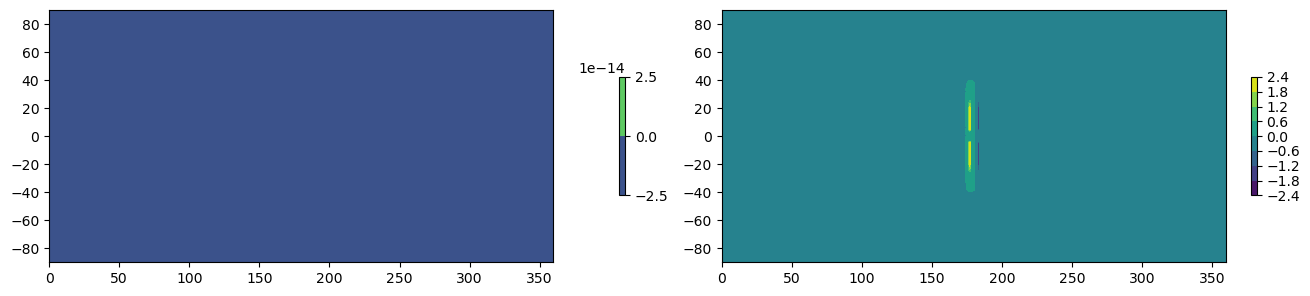

In [67]:
# Plot w field
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(13,6), constrained_layout=True)
plot1 = ax1.contourf(LON, LAT, w_zero)
plot2 = ax2.contourf(LON, LAT, w_nonzero)

ax1.set_aspect('equal')
ax2.set_aspect('equal')

plt.colorbar(plot1,shrink=0.2)
plt.colorbar(plot2,shrink=0.2)

print(f'Maximum vertical velocity is {np.max(w_zero)} m/s')
print(f'Minimum vertical velocity is {np.min(w_zero)} m/s')

print(f'Maximum vertical velocity is {np.max(w_nonzero)} m/s')
print(f'Minimum vertical velocity is {np.min(w_nonzero)} m/s')

In [68]:
# Define interplations to heights.

In [69]:
# Now, compare the final solutions.
t_idx = 40
z_val = 300

lat_crop_up = 40.
lat_cent_down = -40.
lat_ticks = np.linspace(-40.,40.,5)

lon_crop_left = 140.
lon_crop_right = 280.
lon_ticks = np.linspace(140, 280, 8)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON_CROP, LAT_CROP = np.meshgrid(lon_crop, lat_crop)

U_zero = cubic_z_interp(nc_zero['Z3'][t_idx, :, lat_inds, lon_inds], nc_zero['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_nonzero = cubic_z_interp(nc_nonzero['Z3'][t_idx, :, lat_inds, lon_inds], nc_nonzero['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

T_zero = cubic_z_interp(nc_zero['Z3'][t_idx, :, lat_inds, lon_inds], nc_zero['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_nonzero = cubic_z_interp(nc_nonzero['Z3'][t_idx, :, lat_inds, lon_inds], nc_nonzero['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

In [70]:
U_field_vals1 = (U_zero - u0*np.cos(LAT_CROP*deg2rad))/(u0*np.cos(LAT_CROP*deg2rad))
U_field_vals2 = (U_nonzero - u0*np.cos(LAT_CROP*deg2rad))/(u0*np.cos(LAT_CROP*deg2rad))

T_field_vals1 = T_zero - T0
T_field_vals2 = T_nonzero - T0

lon_max_inds = np.where(np.logical_or((lon_crop <= 170),(lon_crop >= 190)))[0]

U_max_crop1 = U_field_vals1[:,lon_max_inds]
U_max_crop2 = U_field_vals2[:,lon_max_inds]

T_max_crop1 = T_field_vals1[:,lon_max_inds]
T_max_crop2 = T_field_vals2[:,lon_max_inds]

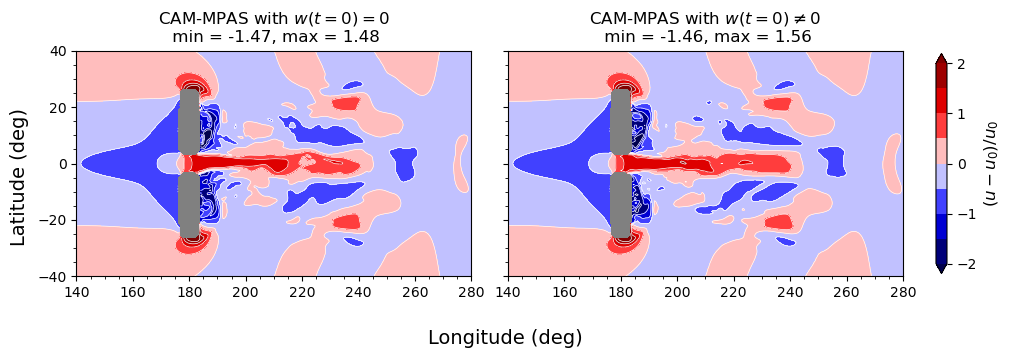

In [71]:
# Plot U field
U_cmap = matplotlib.cm.seismic

U_conts = np.linspace(-2.0, 2.0, 9)
tick_range = np.linspace(-2.0, 2.0, 5)
norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,3.5), sharey=True, constrained_layout=True)
plot1 = ax1.contourf(LON_CROP, LAT_CROP, U_field_vals1, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON_CROP, LAT_CROP, U_field_vals2, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')

ax1.contour(LON_CROP, LAT_CROP, U_field_vals1, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON_CROP, LAT_CROP, U_field_vals2, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')

for ax in (ax1,ax2):
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2,ticks = tick_range,shrink=0.7)
cb.set_label(label=r"$(u - u_0)/u_0$", size=12)

ax1.set_title(r'CAM-MPAS with $w(t=0)=0$' f'\n min = {np.nanmin(U_max_crop1):.2f}, max = {np.nanmax(U_max_crop1):.2f}', size=12)
ax2.set_title(r'CAM-MPAS with $w(t=0) \neq 0$' f'\n min = {np.nanmin(U_max_crop2):.2f}, max = {np.nanmax(U_max_crop2):.2f}', size=12)

fig.supylabel('Latitude (deg)', size=14)
fig.supxlabel('Longitude (deg)', size=14)

# Save the output for the paper

savefig = True
if savefig:
    if rot:
        plt.savefig('figures/mpas_w0_gap_with_rot_U.png')
    else:
        plt.savefig('figures/mpas_w0_gap_omega0_U.png')


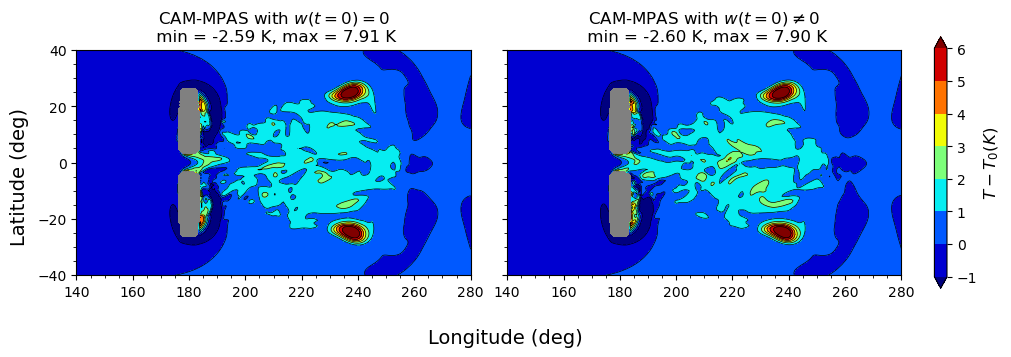

In [72]:
#T_cmap = cmaps.ncl_default
T_cmap = copy.copy(matplotlib.cm.jet)

T_conts = np.linspace(-1, 6, 8)
norm=None
tick_range = np.linspace(-1, 6, 8)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,3.5), sharey=True, constrained_layout=True)
plot1 = ax1.contourf(LON_CROP, LAT_CROP, T_field_vals1, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON_CROP, LAT_CROP, T_field_vals2, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')

# Black contour outlines
ax1.contour(LON_CROP, LAT_CROP, T_field_vals1, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON_CROP, LAT_CROP, T_field_vals2, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')

for ax in (ax1,ax2):
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ticks=tick_range, shrink=0.8)
cb.set_label(label=r"$T - T_0 (K)$", size=12)

ax1.set_title(r'CAM-MPAS with $w(t=0)=0$' f'\n min = {np.nanmin(T_max_crop1):.2f} K, max = {np.nanmax(T_max_crop1):.2f} K', size=12)
ax2.set_title(r'CAM-MPAS with $w(t=0) \neq 0$' f'\n min = {np.nanmin(T_max_crop2):.2f} K, max = {np.nanmax(T_max_crop2):.2f} K', size=12)

fig.supylabel('Latitude (deg)', size=14)
fig.supxlabel('Longitude (deg)', size=14)

savefig = True
if savefig:
    if rot:
        plt.savefig('figures/mpas_w0_gap_with_rot_T.png')
    else:
        plt.savefig('figures/mpas_w0_gap_omega0_T.png')